# Doo — 고객 이탈 예측 모델 비교

동일한 Train/Validation 데이터에서 다섯 후보 모델을 공정하게 비교합니다.

1. Logistic Regression
2. Random Forest
3. XGBoost
4. 확률 보정 SVC
5. Soft Voting

Test 데이터는 최종 모델 확정 전까지 사용하지 않습니다.

## 0. 실행 환경

XGBoost가 설치되어 있지 않으면 `%pip install xgboost` 실행 후 커널을 재시작합니다.

In [1]:
from pathlib import Path
import pickle

import numpy as np
import pandas as pd
import xgboost

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "models":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data" / "preprocessed"
X_train = pd.read_csv(DATA_DIR / "X_train.csv")
y_train = pd.read_csv(DATA_DIR / "y_train.csv")["churn"]
X_val = pd.read_csv(DATA_DIR / "X_val.csv")
y_val = pd.read_csv(DATA_DIR / "y_val.csv")["churn"]

with open(DATA_DIR / "preprocessor.pkl", "rb") as file:
    preprocessor = pickle.load(file)

print("XGBoost version:", xgboost.__version__)
print("X_train:", X_train.shape, "| X_val:", X_val.shape)
print("이탈률 - train:", y_train.mean().round(3), "| val:", y_val.mean().round(3))

XGBoost version: 3.3.0
X_train: (2592, 10) | X_val: (864, 10)
이탈률 - train: 0.494 | val: 0.494


## 1. 후보 모델 정의 및 학습

기존 개별 노트북과 동일한 주요 설정을 사용합니다. Soft Voting이 내부에서 네 모델을 한 번씩 학습하므로, 학습된 내부 모델도 개별 비교에 그대로 활용합니다.

In [2]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier

comparison_logistic_model = LogisticRegression(max_iter=1000, random_state=42)

comparison_random_forest_model = RandomForestClassifier(
    n_estimators=500, max_depth=8, min_samples_leaf=5,
    max_features="sqrt", class_weight="balanced",
    random_state=42, n_jobs=1,
)

comparison_xgboost_model = XGBClassifier(
    n_estimators=300, learning_rate=0.03, max_depth=3, min_child_weight=5,
    subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
    objective="binary:logistic", eval_metric="logloss",
    random_state=42, n_jobs=1, verbosity=0,
)

comparison_svc_model = CalibratedClassifierCV(
    estimator=SVC(
        C=1.0, kernel="rbf", gamma="scale",
        class_weight="balanced", random_state=42,
    ),
    method="sigmoid", cv=5, ensemble=False,
)

comparison_soft_voting_model = VotingClassifier(
    estimators=[
        ("logistic", comparison_logistic_model),
        ("random_forest", comparison_random_forest_model),
        ("xgboost", comparison_xgboost_model),
        ("svc", comparison_svc_model),
    ],
    voting="soft", weights=[1, 1, 1, 1], n_jobs=-1,
)

comparison_soft_voting_model.fit(X_train, y_train)
print("전체 후보 모델 학습 완료")

전체 후보 모델 학습 완료


## 2. 기본 임계값 0.5 비교

In [3]:
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, roc_auc_score,
)

comparison_fitted_models = {
    "Logistic Regression": comparison_soft_voting_model.named_estimators_["logistic"],
    "Random Forest": comparison_soft_voting_model.named_estimators_["random_forest"],
    "XGBoost": comparison_soft_voting_model.named_estimators_["xgboost"],
    "SVC": comparison_soft_voting_model.named_estimators_["svc"],
    "Soft Voting": comparison_soft_voting_model,
}

comparison_probabilities = {}
comparison_default_results = []
for model_name, fitted_model in comparison_fitted_models.items():
    train_pred = fitted_model.predict(X_train)
    val_pred = fitted_model.predict(X_val)
    val_proba = fitted_model.predict_proba(X_val)[:, 1]
    comparison_probabilities[model_name] = val_proba
    comparison_default_results.append({
        "model": model_name,
        "threshold": 0.50,
        "train_accuracy": accuracy_score(y_train, train_pred),
        "val_accuracy": accuracy_score(y_val, val_pred),
        "recall": recall_score(y_val, val_pred),
        "precision": precision_score(y_val, val_pred),
        "f1": f1_score(y_val, val_pred),
        "roc_auc": roc_auc_score(y_val, val_proba),
        "train_val_gap": accuracy_score(y_train, train_pred) - accuracy_score(y_val, val_pred),
    })

comparison_default_df = pd.DataFrame(comparison_default_results).sort_values("f1", ascending=False)
display(comparison_default_df.style.format({
    "threshold": "{:.2f}", "train_accuracy": "{:.3f}",
    "val_accuracy": "{:.3f}", "recall": "{:.3f}",
    "precision": "{:.3f}", "f1": "{:.3f}",
    "roc_auc": "{:.3f}", "train_val_gap": "{:.3f}",
}))

,model,threshold,train_accuracy,val_accuracy,recall,precision,f1,roc_auc,train_val_gap
3,SVC,0.50,0.714,0.711,0.719,0.703,0.711,0.764,0.003
2,XGBoost,0.50,0.753,0.705,0.726,0.692,0.709,0.766,0.049
4,Soft Voting,0.50,0.743,0.707,0.719,0.698,0.708,0.770,0.036
1,Random Forest,0.50,0.790,0.698,0.731,0.681,0.705,0.764,0.092
0,Logistic Regression,0.50,0.699,0.698,0.670,0.704,0.687,0.758,0.001


## 3. Recall 0.80 이상에서 최적 임계값 비교

0.30~0.70을 0.05 간격으로 비교하고, Recall 0.80 이상 후보 중 F1-score가 가장 높은 임계값을 자동 선택합니다.

In [4]:
comparison_thresholds = np.arange(0.30, 0.71, 0.05)
comparison_selected_results = []
comparison_all_threshold_results = {}

for model_name, val_proba in comparison_probabilities.items():
    model_threshold_rows = []
    for threshold in comparison_thresholds:
        threshold_pred = (val_proba >= threshold).astype(int)
        model_threshold_rows.append({
            "model": model_name,
            "threshold": threshold,
            "recall": recall_score(y_val, threshold_pred),
            "precision": precision_score(y_val, threshold_pred, zero_division=0),
            "f1": f1_score(y_val, threshold_pred, zero_division=0),
            "predicted_churn_count": int(threshold_pred.sum()),
        })
    model_threshold_df = pd.DataFrame(model_threshold_rows)
    comparison_all_threshold_results[model_name] = model_threshold_df
    candidates = model_threshold_df[model_threshold_df["recall"] >= 0.80]
    selected = candidates.loc[candidates["f1"].idxmax()] if not candidates.empty else model_threshold_df.loc[model_threshold_df["f1"].idxmax()]
    selected_result = selected.to_dict()
    selected_result["roc_auc"] = roc_auc_score(y_val, val_proba)
    comparison_selected_results.append(selected_result)

comparison_selected_df = (
    pd.DataFrame(comparison_selected_results)
    .sort_values(["f1", "roc_auc"], ascending=False)
    .reset_index(drop=True)
)
display(comparison_selected_df.style.format({
    "threshold": "{:.2f}", "recall": "{:.3f}",
    "precision": "{:.3f}", "f1": "{:.3f}", "roc_auc": "{:.3f}",
}))

,model,threshold,recall,precision,f1,predicted_churn_count,roc_auc
0,XGBoost,0.35,0.869,0.639,0.736,581,0.766
1,Random Forest,0.30,0.913,0.614,0.734,635,0.764
2,Soft Voting,0.30,0.906,0.616,0.734,628,0.770
3,SVC,0.30,0.831,0.640,0.723,555,0.764
4,Logistic Regression,0.30,0.920,0.589,0.718,667,0.758


## 4. 선택 임계값 성능 순위 시각화

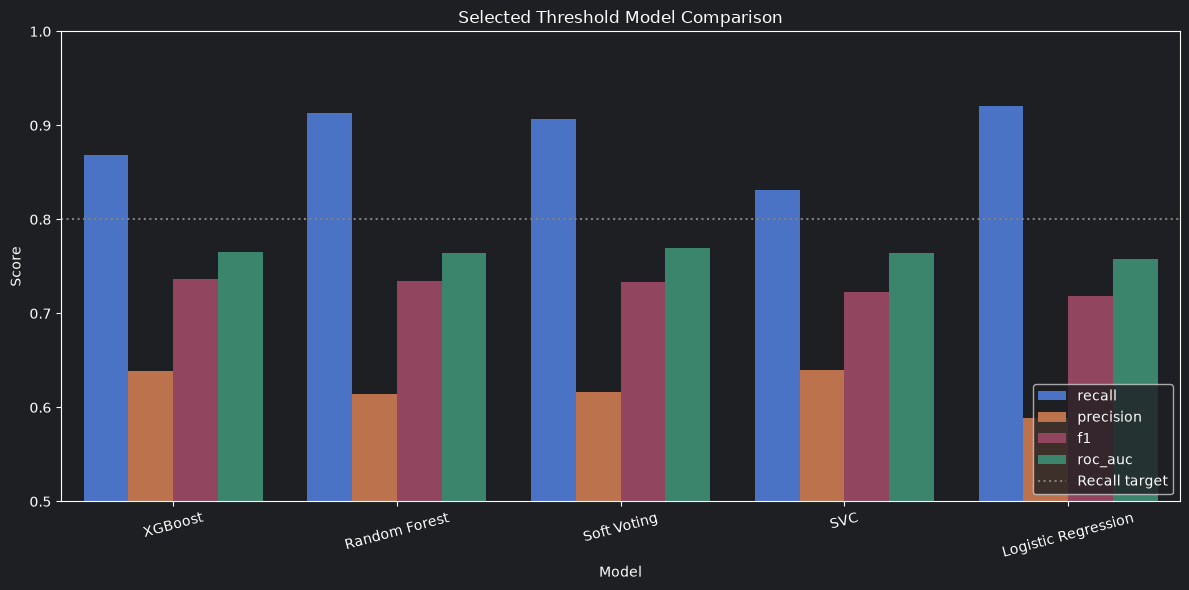

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

comparison_long_df = comparison_selected_df.melt(
    id_vars=["model"], value_vars=["recall", "precision", "f1", "roc_auc"],
    var_name="metric", value_name="score",
)
plt.figure(figsize=(12, 6))
sns.barplot(data=comparison_long_df, x="model", y="score", hue="metric")
plt.axhline(0.80, color="gray", linestyle=":", label="Recall target")
plt.ylim(0.5, 1.0)
plt.title("Selected Threshold Model Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 5. ROC 및 Precision–Recall Curve 비교

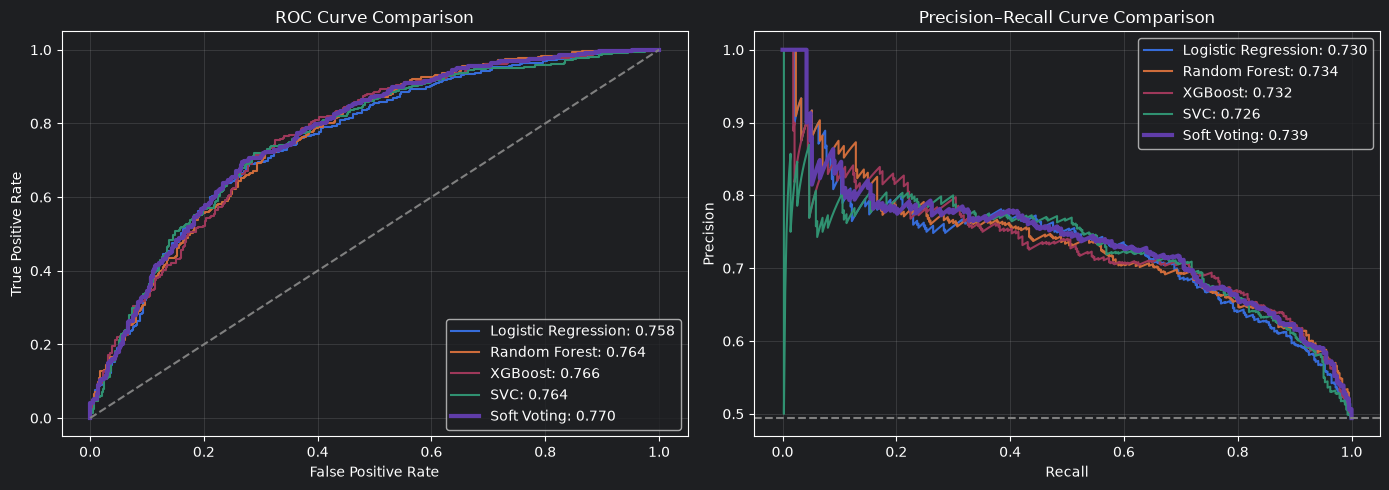

In [6]:
from sklearn.metrics import average_precision_score, precision_recall_curve, roc_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for model_name, val_proba in comparison_probabilities.items():
    fpr, tpr, _ = roc_curve(y_val, val_proba)
    precision, recall, _ = precision_recall_curve(y_val, val_proba)
    roc_auc_value = roc_auc_score(y_val, val_proba)
    average_precision = average_precision_score(y_val, val_proba)
    line_width = 3 if model_name == "Soft Voting" else 1.5
    axes[0].plot(fpr, tpr, linewidth=line_width, label=f"{model_name}: {roc_auc_value:.3f}")
    axes[1].plot(recall, precision, linewidth=line_width, label=f"{model_name}: {average_precision:.3f}")

axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[0].set(xlabel="False Positive Rate", ylabel="True Positive Rate", title="ROC Curve Comparison")
axes[1].axhline(y_val.mean(), linestyle="--", color="gray")
axes[1].set(xlabel="Recall", ylabel="Precision", title="Precision–Recall Curve Comparison")
for axis in axes:
    axis.legend()
    axis.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 6. 모델별 예측 확률 상관관계

상관관계는 모델들이 비슷한 위험 순위를 만드는지 확인하는 참고 지표입니다.

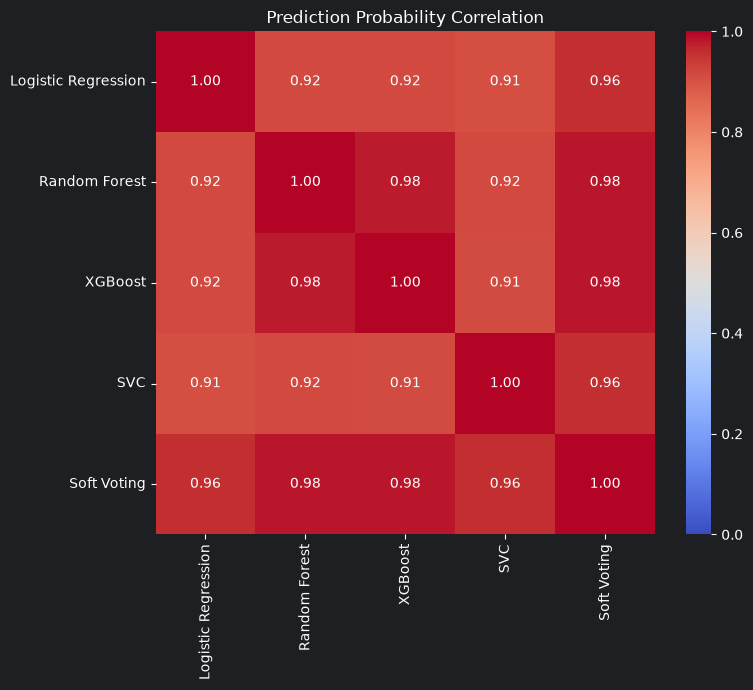

In [7]:
comparison_probability_df = pd.DataFrame(comparison_probabilities)
plt.figure(figsize=(8, 7))
sns.heatmap(comparison_probability_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=0, vmax=1)
plt.title("Prediction Probability Correlation")
plt.tight_layout()
plt.show()

## 7. 결과 해석 가이드

- Recall: 실제 이탈 고객을 얼마나 놓치지 않았는지 확인한다.
- Precision: 이탈 대상으로 선정한 고객 중 실제 이탈 고객의 비율이다.
- F1-score: Recall과 Precision의 균형을 나타낸다.
- ROC-AUC: 특정 임계값과 무관한 전반적인 위험 순위 구분 능력이다.
- predicted_churn_count: 실제 캠페인 대상으로 선정될 고객 수로 비용과 연결된다.
- train_val_gap: 값이 지나치게 크면 과적합 가능성을 의심한다.

이 비교는 한 번의 Validation 분할 결과이므로 미세한 점수 차이만으로 최종 모델을 확정하지 않는다. 상위 1~2개 모델은 Train 내부 교차검증으로 평균과 표준편차를 확인하고 제한적인 하이퍼파라미터 튜닝을 수행한다. 최종 후보를 합의한 후에만 Test 데이터를 한 번 평가한다.